# Проект: Многоцелевая модель для NER + event-CLS

Этот Jupyter-ноутбук - пошаговый шаблон для выполнения проекта по объединённой (multi-task) модели, решающей **NER (BIO, token-level)** и **CLS (document-level multihot событий/отношений)** на датасете NEREL.

Модель должна решать параллельно две задачи: классифицировать токены на BIO-теги и классифицировать текст на принадлежность к 30 классам-характеристикам текста.

Характеристики:
```
['WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN', 'POINT_IN_TIME', 'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM', 'LOCATED_IN', 'AGENT', 'AGE_IS', 'HAS_CAUSE', 'PRODUCES', 'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF', 'MEMBER_OF', 'CONVICTED_OF', 'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF', 'KNOWS', 'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF', 'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS']
```

Внимание: вам нужно реализовать весь рабочий код - в ноутбуке реализована только загрузка датасета. Все остальные ячейки служат как инструкции / места для вашего кода.


#### Структура ноутбука

1. Подготовка окружения (пути, seed, imports)
2. EDA - загрузка данных, обзор, графики, выводы
3. Токенизация, выравнивание меток, DataLoader - реализовать `tokenize_and_align_labels`, Dataset/Collator
4. Модель (JointModel) и кастомный loss (uncertainty-weighting) - реализовать модельный класс и loss
5. Тренировка/валидация - training loop, оптимизатор, scheduler, логирование метрик
6. Инференс и анализ ошибок - реализовать inference pipeline и примеры



##### 1. EDA

Цели:

- Прочитать 3 записи датасета.
- Посчитать встречаемость каждого класса в cls_vec.
- Построить графики: распределение длины текстов, число сущностей на документ.
- Написать 2–3 коротких вывода в Markdown: что можно ожидать при моделировании (редкие типы, длинные документы и т. п.).




In [23]:
features = ['WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN', 'POINT_IN_TIME',
    'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM', 'LOCATED_IN', 'AGENT', 
    'AGE_IS', 'HAS_CAUSE', 'PRODUCES', 'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF', 
    'MEMBER_OF', 'CONVICTED_OF', 'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF', 
    'KNOWS', 'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF', 
    'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS']

Посмотрим на датасет

In [24]:
from datasets import load_dataset
dataset = load_dataset("danasone/nerel")
dataset

DatasetDict({
    train: Dataset({
        features: ['tokens', 'token_spans', 'tags', 'cls_vec', 'text'],
        num_rows: 746
    })
})

Датасет состоит из сплита train. Для обучение выделим из него val и test подвыборки.

Выведем 3 записи датасета

In [25]:
for i in range(3):
    print(f"---\nТЕКСТ {i+1}:\n")
    for k in dataset["train"].features.keys():
        print(f"{k}:")
        print(dataset["train"][i][k])
        print()

---
ТЕКСТ 1:

tokens:
['Пулеметы,', 'автоматы', 'и', 'снайперские', 'винтовки', 'изъяты', 'в', 'арендуемом', 'американцами', 'доме', 'в', 'Бишкеке', '05/08/2008', '10:35', 'БИШКЕК,', '5', 'августа', '/Новости-Грузия/.', 'Правоохранительные', 'органы', 'Киргизии', 'обнаружили', 'в', 'доме,', 'арендуемом', 'гражданами', 'США', 'в', 'Бишкеке,', 'пулеметы,', 'автоматы', 'и', 'снайперские', 'винтовки,', 'сообщает', 'во', 'вторник', 'пресс-служба', 'МВД', 'Киргизии.', '"В', 'ходе', 'проведения', 'оперативно-профилактического', 'мероприятия', 'под', 'кодовым', 'названием', '"Арсенал"', 'в', 'новостройке', 'Ынтымак,', 'в', 'доме,', 'принадлежащем', '66-летнему', 'гражданину', 'Киргизии', 'и', 'арендуемом', 'гражданами', 'США,', 'обнаружены', 'и', 'изъяты:', 'шесть', 'крупнокалиберных', 'пулеметов', 'с', 'оптическим', 'прицелом', 'и', 'с', 'приборами', 'ночного', 'видения,', '26', 'автоматов', 'калибра', '5,56', 'миллиметра,', 'два', 'винчестера', 'марки', 'МОСВЕГА', '12-го', 'калибра,', 'четыр

Посчитаем встречаемость характеристик в датасете

In [26]:
features_cnt = {k: 0 for k in features}

for row in dataset["train"]:
    for feature, flag in zip(features, row["cls_vec"]):
        if flag:
            features_cnt[feature] += 1

features_cnt

{'WORKPLACE': 609,
 'ALTERNATIVE_NAME': 723,
 'WORKS_AS': 678,
 'PARTICIPANT_IN': 656,
 'POINT_IN_TIME': 600,
 'TAKES_PLACE_IN': 545,
 'HEADQUARTERED_IN': 518,
 'ORIGINS_FROM': 449,
 'LOCATED_IN': 454,
 'AGENT': 421,
 'AGE_IS': 535,
 'HAS_CAUSE': 282,
 'PRODUCES': 195,
 'AWARDED_WITH': 137,
 'PART_OF': 214,
 'IDEOLOGY_OF': 119,
 'MEMBER_OF': 150,
 'CONVICTED_OF': 133,
 'INANIMATE_INVOLVED': 174,
 'SUBEVENT_OF': 170,
 'SUBORDINATE_OF': 132,
 'KNOWS': 149,
 'MEDICAL_CONDITION': 106,
 'PARENT_OF': 98,
 'PLACE_RESIDES_IN': 125,
 'OWNER_OF': 114,
 'ABBREVIATION': 142,
 'FOUNDED_BY': 98,
 'ORGANIZES': 121,
 'PENALIZED_AS': 78}

Оценим кол-во сущностей в датасете

In [27]:
from collections import Counter

Counter([item.split("-")[1] for row in dataset["train"] for item in row["tags"] if "B-" in item])

Counter({'PERSON': 7343,
         'PROFESSION': 5193,
         'EVENT': 4318,
         'ORGANIZATION': 3768,
         'DATE': 3548,
         'COUNTRY': 1858,
         'NUMBER': 1260,
         'CITY': 1206,
         'AGE': 901,
         'NATIONALITY': 572,
         'FACILITY': 537,
         'ORDINAL': 482,
         'WORK_OF_ART': 482,
         'AWARD': 450,
         'CRIME': 405,
         'PRODUCT': 379,
         'LAW': 347,
         'DISEASE': 328,
         'STATE_OR_PROVINCE': 326,
         'IDEOLOGY': 277,
         'LOCATION': 275,
         'TIME': 250,
         'MONEY': 230,
         'PENALTY': 206,
         'PERCENT': 102,
         'DISTRICT': 101,
         'RELIGION': 73,
         'LANGUAGE': 67,
         'FAMILY': 30})

Построим график распределения длин текстов и числа сущностей на документ

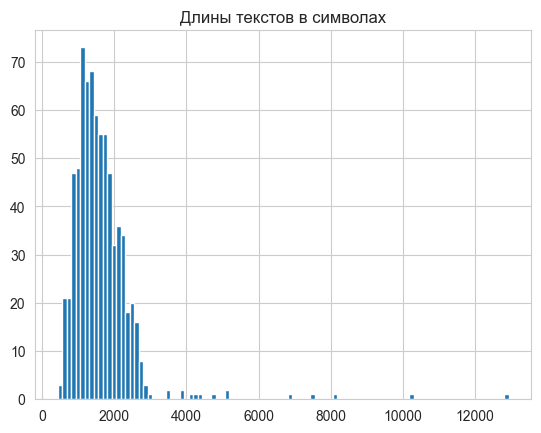

In [28]:
from matplotlib import pyplot as plt

text_lengths = [len(row["text"]) for row in dataset["train"]]

# график распределения длин текстов
plt.hist(text_lengths, bins=100)
plt.title("Длины текстов в символах")
plt.show()

In [29]:
texts = [row["text"] for row in dataset['train']]

print("---\nТоп 3 самых коротких текста\n")
for idx, text in enumerate(sorted(texts, key=len)[:3]):
    print(f"Текст {idx+1}\n")
    print(text + "\n")

---
Топ 3 самых коротких текста

Текст 1

Ларри Пейдж и Сергей Брин перестали возглавлять Google
Создатели Google Ларри Пейдж и Сергей Брин покинули свои места в материнской компании Alphabet.
Генеральным директором Alphabet станет гендиректор Google Сундар Пичаи, который будет совмещать два поста.

В заявлении основателей корпорации говорится:
Сегодня, в 2019 году, если бы компания была человеком, это был бы молодой человек в возрасте 21 года, и пришло время уходить.




Текст 2

Манделу не выписали

Южноафриканский президент Джейкоб Зума заявил, что сообщения о выписке Нельсона Манделы из больницы не соответствуют действительности.

В заявлении президента говорится, что Мандела остается в одной из больниц Претории в критическом, но стабильном состоянии.

95-летний Мандела был госпитализирован 8 июня 2013 года с диагнозом «рецидив легочной инфекции».

Бывший президент ЮАР и лауреат Нобелевской премии мира весь прошлый год наблюдался в стационаре, лишь ненадолго его покидая.


Текст 3


In [30]:
print("Топ 3 самых длинных текста\n")
for idx, text in enumerate(sorted(texts, key=len, reverse=True)[:3]):
    print(f"---\nТекст {idx+1}\n")
    print(text + "\n")

Топ 3 самых длинных текста

---
Текст 1

Политический кризис в Чехии: движение в сторону "корпоративного государства"

17 июня 2013 года премьер-министр Петр Нечас подал заявление о своей отставке президенту Чехии Милошу Земану. Отставка премьера по чешской конституции означает роспуск всего правительства. После этого события прошла вторая неделя, а конца правительственному кризису в Чехии не видно. Связано это с тем, что над его разрешением каждая в своих интересах работают три силы: правительственная правоконсервативная коалиция с ведущей двойкой партий - Гражданская демократическая партия (ODS), "Традиция. Ответственность. Процветание 09" (TOP 09); левая оппозиция - Чешская социал-демократическая партия (CSSD) и Коммунистическая партия Чехии и Моравии (KSCM); новый президент Чехии Милош Земан.(1)

Причина затягивания кризиса - президент. Сбылись прогнозы тех политических обозревателей, которые предсказывали, что властный по своей натуре Земан не станет довольствоваться чисто декорат

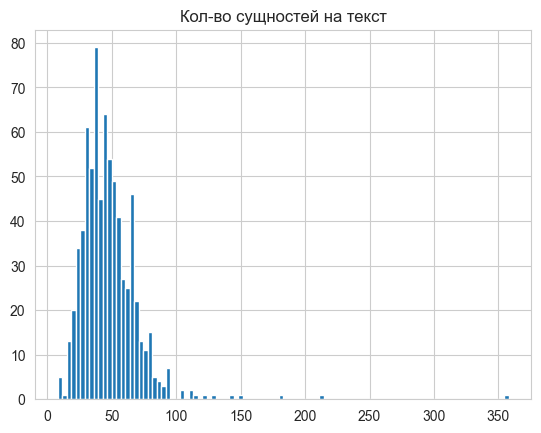

In [31]:
entity_cnt = []
for row in dataset["train"]:
    entity_cnt.append(len([item for item in row["tags"] if item.startswith("B-")]))

plt.hist(entity_cnt, bins=100)
plt.title("Кол-во сущностей на текст")
plt.show()

### Выводы по EDA
- и сущности и отношения (характеристики) которые нужно распознавать представлены в датасете неравномерно, распознавание редких сущности будет сложнее выучить
- также будет сложно выучить распознавание сущностей в длинных текстах (в датасете есть выбросы с очень большим кол-вом символов), где модели нужно выстаивать связи большого кол-ва токенов друг с другом

---

##### 3. Токенизация и выравнивание меток

Задачи:

- Выбрать `AutoTokenizer(..., use_fast=True)`.
- Реализовать `tokenize_and_align_labels(examples, tokenizer, label2id, max_length)`:
  - Токенизировать текст (return_offsets_mapping
  - Преобразовать word-level BIO метки в token-level метки (subword → label = -100 / ignore_index, для первых субтокенов ставится соответствующий тег `B-`/`I-`)
  - Вернуть словарь с `input_ids`, `attention_mask`, `labels` (token-level), `cls_labels`

- Собрать `torch.utils.data.Dataset` и `DataLoader`. Можно использовать `DataCollatorForTokenClassification` либо сделать кастомный collator, который возвращает батчи с `cls_labels`.



---
Тексты в датасете на русском. Нужно использовать токенизатор, который поддерживает русский язык.

Посмотрим на длину текстов в токенах

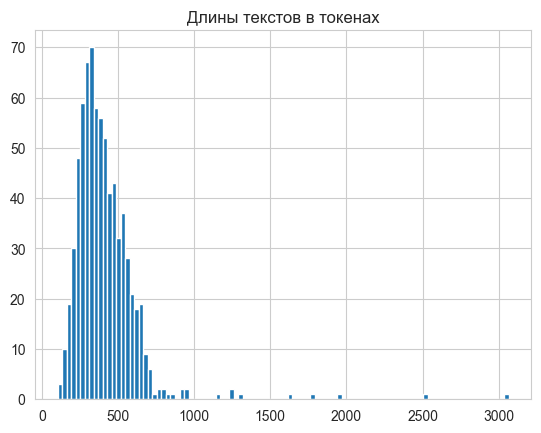

In [32]:
from transformers import AutoTokenizer

model_name = 'markussagen/xlm-roberta-longformer-base-4096'
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenized_texts = tokenizer(list(dataset["train"]["text"]), truncation=False)

token_lengths = [len(tokens) for tokens in tokenized_texts["input_ids"]]
plt.hist(token_lengths, bins=100)
plt.title("Длины текстов в токенах")
plt.show()

Много текстов довольно длинные, поэтому был выбран трансформер xlm-roberta-longformer-base-4096 - мультиязычный roBERTa трансформер обученный с длиной контекста до 4096 токенов.

Перенесем BIO-метки с уровня слов на уровень токенов

In [33]:
entity_labels = list(set([item.split("-")[1] for row in dataset["train"] for item in row["tags"] if "B-" in item]))
label2id = {lab: i for i, lab in enumerate(entity_labels)}
id2label = {i: lab for lab, i in label2id.items()}

def tokenize_and_align_labels(tokenizer, label2id, max_length=128):
    def _tokenize_and_align_labels(examples):
        tokenized = tokenizer(
            list(examples["text"]),
            return_offsets_mapping=True,
            padding='max_length',
            truncation=True,
            max_length=max_length)
        labels = []
        for i, word_labels in enumerate(examples["tags"]):
            word_ids = tokenized.word_ids(batch_index=i)
            label_ids = []
            prev_word_idx = None
            for word_idx in word_ids:
                if word_idx is None:
                    label_ids.append(-100)
                elif word_idx != prev_word_idx:
                    label_id = -100
                    word_entity = "O"
                    if len(word_labels[word_idx].split("-")) == 2:
                        word_entity = word_labels[word_idx].split("-")[1]
                    label_id = label2id.get(word_entity, -100)
                    label_ids.append(label_id)
                else:
                    label_ids.append(-100)
                prev_word_idx = word_idx
            labels.append(label_ids)
        tokenized["labels"] = labels
        return tokenized
    return _tokenize_and_align_labels

tokenized_dataset = dataset["train"].map(
    tokenize_and_align_labels(tokenizer, label2id, max_length=1024),
    batched=True,
    remove_columns=["text", "tokens", "tags", "token_spans"],
)

Map:   0%|          | 0/746 [00:00<?, ? examples/s]

Проверим что перенос корректный

In [34]:
list(zip(
    tokenizer.convert_ids_to_tokens(tokenized_dataset["input_ids"][0]),
    tokenized_dataset["labels"][0],
    [id2label.get(tkn, "") for tkn in tokenized_dataset["labels"][0]]
))[:100]

[('<s>', -100, ''),
 ('▁Пу', -100, ''),
 ('ле', -100, ''),
 ('ме', -100, ''),
 ('ты', -100, ''),
 (',', -100, ''),
 ('▁автоматы', -100, ''),
 ('▁и', -100, ''),
 ('▁с', -100, ''),
 ('най', -100, ''),
 ('пер', -100, ''),
 ('ские', -100, ''),
 ('▁ви', -100, ''),
 ('нтов', -100, ''),
 ('ки', -100, ''),
 ('▁из', -100, ''),
 ('ъя', -100, ''),
 ('ты', -100, ''),
 ('▁в', -100, ''),
 ('▁аренду', -100, ''),
 ('ем', -100, ''),
 ('ом', -100, ''),
 ('▁американ', 8, 'NATIONALITY'),
 ('цами', -100, ''),
 ('▁доме', -100, ''),
 ('▁в', -100, ''),
 ('▁Бишкек', 17, 'CITY'),
 ('е', -100, ''),
 ('▁05', 16, 'TIME'),
 ('/08', -100, ''),
 ('/2008', -100, ''),
 ('▁10', 16, 'TIME'),
 (':35', -100, ''),
 ('▁Б', 17, 'CITY'),
 ('ИШ', -100, ''),
 ('КЕ', -100, ''),
 ('К', -100, ''),
 (',', -100, ''),
 ('▁5', 1, 'DATE'),
 ('▁августа', 1, 'DATE'),
 ('▁/', 14, 'ORGANIZATION'),
 ('Ново', -100, ''),
 ('сти', -100, ''),
 ('-', -100, ''),
 ('Г', -100, ''),
 ('ру', -100, ''),
 ('зия', -100, ''),
 ('/', -100, ''),
 ('.', -100

Объявляем `DataLoader` со стандартным `collate_fn=DataCollatorForTokenClassification`

In [35]:
from transformers import DataCollatorForTokenClassification
from torch.utils.data import DataLoader

data_collator = DataCollatorForTokenClassification(tokenizer)
train_dataloader = DataLoader(tokenized_dataset, batch_size=16, shuffle=True, collate_fn=data_collator)

---

##### 4. Модель: `JointModel` + custom loss (uncertainty weighting)


У нас готовы все данные, давайте создадим модель, которую потом будем обучать. К базовой модели, которую вы взяли на этапе выбора токенизатора, добавьте слой Dropout, линейный слой классификации сущностей и линейный слой классификации характеристик. Обратите внимание, что характеристики связаны со всем текстом, поэтому надо из всех эмбеддингов выбрать один, например, с помощью `[CLS]` пулинга. Обратите внимание, что `[CLS]` в квадратных скобках обозначает специальный токен, вектор которого нужно использовать для классификации текста.

Также реализуйте лосс-функцию для совместного обучения. Самый простой —  сумма лоссов для каждой задачи loss = token_loss + cls_loss.

In [ ]:
# import torch
# from torch import nn
# from transformers import AutoModel
# from transformers import logging as transformers_logging
# transformers_logging.set_verbosity_error()


# class JointModel(nn.Module):
#     def __init__(self, config, label2id, features):
#         super().__init__()
#         self.base_model = AutoModel.from_pretrained(config.BASE_MODEL_NAME, ignore_mismatched_sizes=True)
#         self.dropout = nn.Dropout(p=config.DROPOUT)
#         self.use_uncertainty_weight = config.USE_UNCERTAINTY_WEIGHT

#         self.entity_cnt = len(label2id)
#         self.features_cnt = len(features)

#         self.token_fc = nn.Linear(self.base_model.config.hidden_size, self.entity_cnt)
#         self.cls_fc = nn.Linear(self.base_model.config.hidden_size, self.features_cnt)

#         self.log_sigma_token = nn.Parameter(torch.tensor(0.0))
#         self.log_sigma_cls = nn.Parameter(torch.tensor(0.0)) 
#         self.token_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
#         self.cls_loss_fn = nn.BCEWithLogitsLoss()

#     def forward(self, input_ids, attention_mask, labels, cls_vec):
#         embeddings = self.base_model(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )
#         dropout_embeddings = self.dropout(embeddings.last_hidden_state)
#         token_logits = self.token_fc(dropout_embeddings)
#         cls_logits = self.cls_fc(dropout_embeddings[:, 0])

#         token_loss = self.token_loss_fn(token_logits.view(-1, self.entity_cnt), labels.view(-1))
#         cls_loss = self.cls_loss_fn(cls_logits, cls_vec.float())

#         loss_token_term, loss_cls_term = torch.const(0.), 
#         if self.use_uncertainty_weight:
#             loss_token_term = torch.exp(-2.0 * self.log_sigma_token) * token_loss + self.log_sigma_token
#             loss_cls_term = torch.exp(-2.0 * self.log_sigma_cls) * cls_loss + self.log_sigma_cls
#             loss = loss_token_term + loss_cls_term
#         else:
#             loss = token_loss + cls_loss

#         return {
#             "token_logits": token_logits,
#             "cls_logits": cls_logits,
#             "loss": loss,
#         }

In [36]:
import torch
from torch import nn
from transformers import AutoModel
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()


class JointModel(nn.Module):
    def __init__(self, config, label2id, features, pos_weight=None):
        super().__init__()
        self.base_model = AutoModel.from_pretrained(config.BASE_MODEL_NAME, ignore_mismatched_sizes=True)
        self.dropout = nn.Dropout(p=config.DROPOUT)
        self.use_uncertainty_weight = config.USE_UNCERTAINTY_WEIGHT

        self.entity_cnt = len(label2id)
        self.features_cnt = len(features)
        self.cls_term_multiplier = config.CLS_TERM_MULTIPLIER

        self.token_fc = nn.Linear(self.base_model.config.hidden_size, self.entity_cnt)
        self.cls_fc = nn.Linear(self.base_model.config.hidden_size, self.features_cnt)

        self.log_sigma_token = nn.Parameter(torch.tensor(0.0))
        self.log_sigma_cls = nn.Parameter(torch.tensor(0.0))
        self.token_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
        if pos_weight is not None:
            pos_weight = torch.tensor(pos_weight, dtype=torch.float)
        self.cls_loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.init_weights()

    def init_weights(self):
        nn.init.xavier_uniform_(self.cls_fc.weight)
        nn.init.zeros_(self.cls_fc.bias)

    def forward(self, input_ids, attention_mask, labels, cls_vec):
        embeddings = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        dropout_embeddings = self.dropout(embeddings.last_hidden_state)
        token_logits = self.token_fc(dropout_embeddings)
        # CLS-logits
        # cls_logits = self.cls_fc(dropout_embeddings[:, 0])

        # mean pooling
        mask = attention_mask.unsqueeze(-1)
        masked = dropout_embeddings * mask
        mean_pooled = masked.sum(1) / mask.sum(1).clamp(min=1)
        cls_logits = self.cls_fc(mean_pooled)

        token_loss = self.token_loss_fn(token_logits.view(-1, self.entity_cnt), labels.view(-1))
        cls_loss = self.cls_loss_fn(cls_logits, cls_vec.float())

        loss_token_term, loss_cls_term = torch.tensor(0.0), torch.tensor(0.0)
        if self.use_uncertainty_weight:
            loss_token_term = torch.exp(-2.0 * self.log_sigma_token) * token_loss + self.log_sigma_token
            loss_cls_term = torch.exp(-2.0 * self.log_sigma_cls) * cls_loss + self.log_sigma_cls
            loss = loss_token_term + loss_cls_term * self.cls_term_multiplier
        else:
            loss = token_loss + cls_loss * self.cls_term_multiplier

        return {
            "token_logits": token_logits,
            "cls_logits": cls_logits,
            "loss": loss,
            "loss_token_term": loss_token_term,
            "loss_cls_term": loss_cls_term,
        }

##### 5. Training / Validation



Когда логика модели прописана, можем начать ее обучать. Вот основые шаги, которые нужно выполнить:
- Настройте оптимизатор, LR-scheduler, gradient clipping.
- Обучите на достаточном количестве эпох. Можете воспользоваться значением с предыдущих уроков. Можно начать с 5 эпох и увеличивать, пока лосс не перестанет уменьшаться или пока не увидите переобучение.
- Рассчитайте качество на тестовой выборке. Используйте f1_score из библиотеки sklearn для каждой задачи:
   - По всем сущностям — F1 macro
   - По всем классам — F1 micro
- Соберите логи: для каждой эпохи выведите loss, token_f1, cls_f1.
- Сделайте выводы по проведённому обучению. На какой эпохе она обучилась, насколько лосс на обучении отличается от лосса на валидации на каждой задачи.

In [37]:
import torch
import random
import numpy as np
from tqdm.auto import tqdm


class Config:
    SEED = 42
    BASE_MODEL_NAME = "markussagen/xlm-roberta-longformer-base-4096"

    # Гиперпараметры
    BATCH_SIZE = 16
    TOKEN_LEARNING_RATE = 1e-5
    CLS_LEARNING_RATE = 1e-5
    WEIGHT_DECAY = 1e-5
    EPOCHS = 2
    DROPOUT = 0.5
    MAX_TOKENS = 1024
    UNFREEZE_LAYERS_PATTERN = ""
    USE_UNCERTAINTY_WEIGHT = True

    MODELS_PATH = "models"


def set_seed(seed=42):
    """
    Устанавливает сиды для всех источников случайности в PyTorch.
    """
    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Python
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # CuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Для некоторых операций — принудительно детерминистические алгоритмы
    torch.use_deterministic_algorithms(True, warn_only=True)

config = Config()
set_seed(config.SEED)

Изучим базовую модель, чтобы понять как к ней подступиться

In [264]:
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

print(AutoModel.from_pretrained(config.BASE_MODEL_NAME, ignore_mismatched_sizes=True))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel(
  (embeddings): XLMRobertaEmbeddings(
    (word_embeddings): Embedding(250002, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(4098, 768, padding_idx=1)
  )
  (encoder): XLMRobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x XLMRobertaLayer(
        (attention): XLMRobertaAttention(
          (self): XLMRobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): XLMRobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=Tr

Получается слой эмбедингов, 12 энкодеров и pooler слой для работы с представление CLS-токена. Для NER на нужен выход последнего энкодера, а для второй задачи мультиклассовой классификации нужен выход pooler-слоя

In [ ]:
import torch
from torch.utils.data import random_split
from transformers import DataCollatorForTokenClassification
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from torch.utils.data import Subset

tokenizer = AutoTokenizer.from_pretrained(config.BASE_MODEL_NAME, use_fast=True)

data_collator = DataCollatorForTokenClassification(tokenizer)

entity_labels = list(set([item.split("-")[1] for row in dataset["train"] for item in row["tags"] if "B-" in item]))
label2id = {lab: i for i, lab in enumerate(entity_labels)}

tokenized_dataset = dataset["train"].map(
    tokenize_and_align_labels(tokenizer, label2id, max_length=config.MAX_TOKENS),
    batched=True,
    remove_columns=["text", "tokens", "tags", "token_spans"],
)

# tokenized_dataset = Subset(tokenized_dataset, list(range(50)))

train_dataset, val_dataset = random_split(tokenized_dataset, [0.9, 0.1], generator=torch.Generator().manual_seed(config.SEED))

train_dataloader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=data_collator)
val_dataloader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=data_collator)

In [266]:
from torchinfo import summary
import re


def set_requires_grad(module, unfreeze_pattern="", verbose=False):
    if len(unfreeze_pattern) == 0:
        for name, param in module.named_parameters():
            param.requires_grad = False
        return
    pattern = re.compile(unfreeze_pattern)
    for name, param in module.named_parameters():
        if pattern.search(name):
            param.requires_grad = True
            if verbose:
                print(f"Разморожен слой: {name}")
        else:
            param.requires_grad = False


model = JointModel(config, label2id, features)
set_requires_grad(model.base_model, unfreeze_pattern=config.UNFREEZE_LAYERS_PATTERN, verbose=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
print(f"Модель перенесена на девайс: {device}")
if torch.cuda.is_available():
    print(f"Девайс: {torch.cuda.get_device_name(0)}")

optimizer = torch.optim.AdamW([
    # {'params': model.base_model.parameters(), 'lr': config.LEARNING_RATE, 'weight_decay': config.WEIGHT_DECAY},
    {'params': model.token_fc.parameters(), 'lr': config.TOKEN_LEARNING_RATE, 'weight_decay': config.WEIGHT_DECAY},
    {'params': model.cls_fc.parameters(), 'lr': config.CLS_LEARNING_RATE, 'weight_decay': config.WEIGHT_DECAY},
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')

print("Сводка о модели")
summary(model)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Модель перенесена на девайс: cpu
Сводка о модели


Layer (type:depth-idx)                                       Param #
JointModel                                                   2
├─XLMRobertaModel: 1-1                                       --
│    └─XLMRobertaEmbeddings: 2-1                             --
│    │    └─Embedding: 3-1                                   (192,001,536)
│    │    └─Embedding: 3-2                                   (768)
│    │    └─LayerNorm: 3-3                                   (1,536)
│    │    └─Dropout: 3-4                                     --
│    │    └─Embedding: 3-5                                   (3,147,264)
│    └─XLMRobertaEncoder: 2-2                                --
│    │    └─ModuleList: 3-6                                  (85,054,464)
│    └─XLMRobertaPooler: 2-3                                 --
│    │    └─Linear: 3-7                                      (590,592)
│    │    └─Tanh: 3-8                                        --
├─Dropout: 1-2                                         

In [ ]:
from sklearn.metrics import f1_score
import json
import os
from datetime import datetime
from hashlib import sha256


def train_model(config, train_dataloader, val_dataloader):
    train_history = []
    for epoch in range(1, config.EPOCHS + 1):
        model.train()
        device = next(model.parameters()).device

        best_loss = 100
        epoch_loss = 0.0
        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch}"):
            inputs = {k: v.to(device) for k, v in batch.items()}
            if 'offset_mapping' in inputs:
                del inputs['offset_mapping']
            optimizer.zero_grad()
            outputs = model(**inputs)
            loss = outputs["loss"]
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        train_loss = epoch_loss / len(train_dataloader)
        val_losses = validate_model(model, val_dataloader)
        scheduler.step(val_losses["loss"])
        current_lr = optimizer.param_groups[0]['lr']

        train_history_metadatum = {
            "epoch": epoch,
            "learning_rate": current_lr,
            "train_loss": train_loss,
            "val_loss": val_losses["loss"],
            "val_token_f1": val_losses["token_f1"],
            "val_cls_f1": val_losses["cls_f1"]
        }
        train_history.append(train_history_metadatum)
        if val_losses["loss"] < best_loss:
            best_loss = val_losses["loss"]
            save_model(model, config,
                additional_info=dict(train_history=train_history, **train_history_metadatum))

        print(
            f"train loss: {train_loss:.4f}\n"
            f"val loss: {val_losses['loss']:.4f}\n"
            f"val token F1: {val_losses['token_f1']:.4f}\n"
            f"val cls F1: {val_losses['cls_f1']:.4f}"
        )
    return train_history


def validate_model(model, val_dataloader):
    model.eval()
    device = next(model.parameters()).device
    epoch_val_loss = 0.0
    token_labels, token_predicts, cls_labels, cls_predicts = [], [], [], []
    with torch.no_grad():
        for batch in val_dataloader:
            inputs = {k: v.to(device) for k, v in batch.items()}
            if 'offset_mapping' in inputs:
                del inputs['offset_mapping']
            outputs = model(**inputs)
            loss = outputs["loss"]
            epoch_val_loss += loss.item()

            token_preds = torch.argmax(outputs["token_logits"], dim=-1).view(-1).cpu().tolist()
            labels = inputs["labels"].view(-1).cpu().tolist()
            for p, t in zip(token_preds, labels):
                if t != -100:
                    token_labels.append(int(t))
                    token_predicts.append(int(p))

            cls_labels.extend(inputs["cls_vec"].cpu().numpy())
            probs = torch.sigmoid(outputs["cls_logits"])
            cls_predicts.extend((probs > 0.5).int().cpu().numpy())

    token_f1 = f1_score(token_labels, token_predicts, average="macro", zero_division=0)
    cls_f1 = f1_score(cls_labels, cls_predicts, average="micro", zero_division=0)

    return {
        "loss": epoch_val_loss / len(val_dataloader),
        "token_f1": token_f1,
        "cls_f1": cls_f1,
        "token_labels": token_labels,
        "token_predicts": token_predicts,
        "cls_labels": cls_labels,
        "cls_predicts": cls_predicts,
    }


def serialize_config(config):
    attrs_source = dict(config.__class__.__dict__)
    attrs = {k: v for k, v in attrs_source.items() if not k.startswith("__") and not callable(v)}
    return json.dumps(attrs, indent=4)


def load_config(json_data):
    if isinstance(json_data, str):
        data = json.loads(json_data)
    else:
        data = json_data 
    config_instance = Config()
    for key, value in data.items():
        setattr(config_instance, key, value)
    return config_instance


def save_model(model, config, additional_info={}):
    config_serialized = serialize_config(config)
    current_datetime = datetime.now()
    model_id = sha256(f"{config_serialized}/{current_datetime}".encode()).hexdigest()
    
    metadata = dict()
    metadata_path = f"{config.MODELS_PATH}/metadata.json"
    if os.path.exists(metadata_path):
        with open(metadata_path, "r+") as file:
            metadata = json.load(file)
    metadata[model_id] = {
        "config": config_serialized,
        **additional_info,
    }
    with open(metadata_path, "w") as file:
        json.dump(metadata, file, indent=4)
    
    model_path = f"{config.MODELS_PATH}/{model_id}.pth"
    torch.save(model.state_dict(), model_path)

    return model_path

In [289]:
_ = train_model(config, train_dataloader, val_dataloader)

Epoch 1:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1:
train loss: 4.2369
val loss: 4.2065
val token F1: 0.0066
val cls F1: 0.4429


Epoch 2:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 2:
train loss: 4.2235
val loss: 4.2041
val token F1: 0.0068
val cls F1: 0.4539


In [58]:
import json

with open("models/metadata.json", "r") as file:
    metadata = json.load(file)

best_loss = 100
for model_id, metadatum in metadata.items():
    if metadatum["val_loss"] < best_loss:
        best_loss = metadatum["val_loss"]
        best_model_id = model_id

best_train_history = metadata[best_model_id]["train_history"]
print(f"best_model_id: {best_model_id}")

best_model_id: 3cf3731d1ba46137d7d3999dc4b7e3a99917711b5348701239d0f46b0d2e4dd5


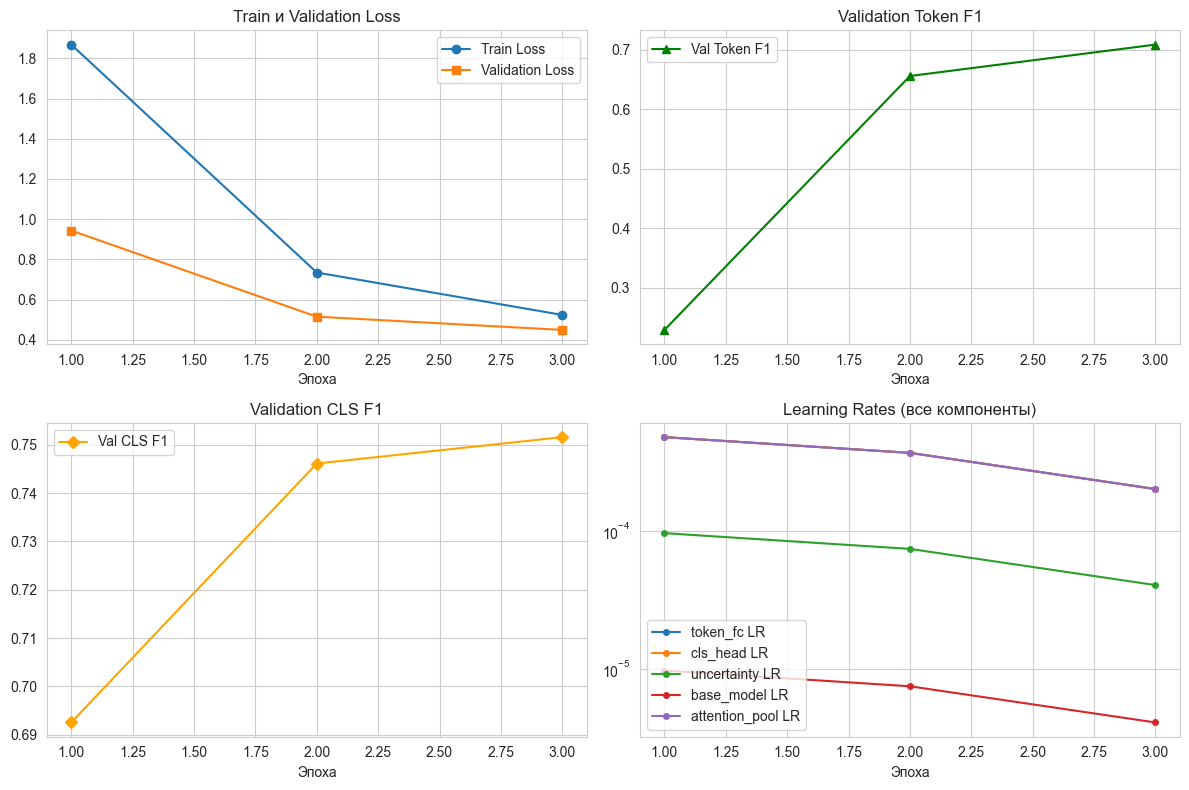

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

epochs = [entry['epoch'] for entry in best_train_history]
train_loss = [entry['train_loss'] for entry in best_train_history]
val_loss = [entry['val_loss'] for entry in best_train_history]
val_token_f1 = [entry['val_token_f1'] for entry in best_train_history]
val_cls_f1 = [entry['val_cls_f1'] for entry in best_train_history]

all_lr_types = set()
for entry in best_train_history:
    if 'learning_rates' in entry:
        all_lr_types.update(entry['learning_rates'].keys())
lr_data = {lr_type: [] for lr_type in all_lr_types}

for entry in best_train_history:
    if 'learning_rates' in entry:
        lr_dict = entry['learning_rates']
        for lr_type in all_lr_types:
            lr_data[lr_type].append(lr_dict.get(lr_type, None))

# График 1: Train и Validation Loss
plt.subplot(2, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='s')
plt.xlabel('Эпоха')
plt.title('Train и Validation Loss')
plt.legend()
plt.grid(True)

# График 2: Validation Token F1
plt.subplot(2, 2, 2)
plt.plot(epochs, val_token_f1, label='Val Token F1', color='green', marker='^')
plt.xlabel('Эпоха')
plt.title('Validation Token F1')
plt.legend()
plt.grid(True)

# График 3: Validation CLS F1
plt.subplot(2, 2, 3)
plt.plot(epochs, val_cls_f1, label='Val CLS F1', color='orange', marker='D')
plt.xlabel('Эпоха')
plt.title('Validation CLS F1')
plt.legend()
plt.grid(True)

# График 4: Learning Rate
plt.subplot(2, 2, 4)

for idx, lr_type in enumerate(lr_data.keys()):
    data = lr_data[lr_type]
    plt.plot(epochs, data, label=f'{lr_type} LR', marker='o', markersize=4)

plt.xlabel('Эпоха')
plt.title('Learning Rates (все компоненты)')
plt.legend()
plt.grid(True)
plt.yscale('log')

# Финальная настройка
plt.tight_layout()
plt.show()

##### 6. Инференс, квантизация и анализ ошибок

Проведите качественный анализ на 8–10 примерах: где NER ошибается? Какие типы сущностей плохо определяются? Насколько квантизация может ускорить инференс и сильно ли она ухудшает модель?


##### Заключение

Этот шаблон даёт вам чёткую дорожную карту и рабочие точки, где нужно реализовать код. В ноутбуке предоставлены только парсеры строкового формата - всё остальное вы пишете самостоятельно: токенизация/выравнивание меток, датасеты, модель, loss, тренировка и анализ.

Удачи - приступайте к реализации прямо в ноутбуке!

In [51]:
best_config = load_config(metadata[best_model_id]["config"])

print(f"Epoch: {metadata[best_model_id]["epoch"]}")
print("Config:")
print(metadata[best_model_id]["config"])

Epoch: 25
Config:
{
    "SEED": 42,
    "BASE_MODEL_NAME": "DeepPavlov/rubert-base-cased",
    "BATCH_SIZE": 16,
    "BASE_LEARNING_RATE": 2e-05,
    "TOKEN_LEARNING_RATE": 0.0005,
    "CLS_LEARNING_RATE": 0.0005,
    "UNCERTAINTY_LEARNING_RATE": 0.0001,
    "WEIGHT_DECAY": 0.01,
    "EPOCHS": 10,
    "DROPOUT": 0.1,
    "MAX_TOKENS": 512,
    "UNFREEZE_LAYERS_PATTERN": "pooler|encoder\\.layer\\.(9|10|11)",
    "USE_UNCERTAINTY_WEIGHT": false,
    "CLS_TERM_MULTIPLIER": 10.0,
    "MODELS_PATH": "models"
}


In [61]:
best_model = JointModel(best_config, label2id, features)
best_model.load_state_dict(torch.load(f"{config.MODELS_PATH}/{best_model_id}.pth", map_location=torch.device('cpu')))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RuntimeError: Error(s) in loading state_dict for JointModel:
	Missing key(s) in state_dict: "cls_fc.weight", "cls_fc.bias". 
	Unexpected key(s) in state_dict: "attention_pool.weight", "attention_pool.bias", "cls_head.0.weight", "cls_head.0.bias", "cls_head.1.weight", "cls_head.1.bias", "cls_head.4.weight", "cls_head.4.bias", "cls_loss_fn.pos_weight". 
	size mismatch for base_model.embeddings.word_embeddings.weight: copying a param with shape torch.Size([250002, 768]) from checkpoint, the shape in current model is torch.Size([119547, 768]).
	size mismatch for base_model.embeddings.position_embeddings.weight: copying a param with shape torch.Size([4098, 768]) from checkpoint, the shape in current model is torch.Size([512, 768]).
	size mismatch for base_model.embeddings.token_type_embeddings.weight: copying a param with shape torch.Size([1, 768]) from checkpoint, the shape in current model is torch.Size([2, 768]).

~~Тут я рыбу заворачивал~~ тут служебный код, чтобы копипастить модели с сервера и чистить лишние модели

In [1]:
import paramiko
import os
import stat
from pathlib import Path
from tqdm.auto import tqdm
import math

def convert_size(size_bytes):
    """Конвертирует размер файла из байт в удобочитаемый формат"""
    if size_bytes == 0:
        return "0 B"
    size_names = ["B", "KB", "MB", "GB", "TB"]
    i = int(math.floor(math.log(size_bytes, 1024)))
    p = math.pow(1024, i)
    s = round(size_bytes / p, 2)
    return f"{s} {size_names[i]}"


def copy_new_files_sftp(
    hostname,
    username,
    password=None,
    private_key_path=None,
    remote_dir='/path/to/remote/directory',
    local_dir='/path/to/local/directory',
    force_copy=None,
):
    """
    Копирует файлы с удалённой машины, только если их ещё нет в локальной директории.
    """
    # Создаём локальную директорию, если её нет
    Path(local_dir).mkdir(parents=True, exist_ok=True)

    # Настройка SSH-клиента
    ssh_client = paramiko.SSHClient()
    ssh_client.set_missing_host_key_policy(paramiko.AutoAddPolicy())

    try:
        # Подключение (с паролем или приватным ключом)
        if private_key_path:
            ssh_client.connect(
                hostname=hostname,
                username=username,
                key_filename=private_key_path,
                port=22,
                timeout=30,
                banner_timeout=60,
                auth_timeout=30,
            )
        else:
            ssh_client.connect(
                hostname=hostname,
                username=username,
                password=password
            )

        # Создание SFTP-сессии
        sftp = ssh_client.open_sftp()

        # Получение списка файлов на удалённой машине
        remote_files = sftp.listdir(remote_dir)

        copied_count = 0
        for filename in tqdm(remote_files):
            remote_path = f"{remote_dir}/{filename}"
            file_attr = sftp.lstat(remote_path)
            if stat.S_ISLNK(file_attr.st_mode):
                print(f"Пропущен симлинк: {filename}")
                continue

            file_attr = sftp.stat(remote_path)
            file_size_bytes = file_attr.st_size
            # Конвертируем в удобочитаемый формат
            file_size_readable = convert_size(file_size_bytes)

            local_path = os.path.join(local_dir, filename)

            if force_copy is None:
                force_copy = []
            # Проверяем, существует ли файл локально
            if not os.path.exists(local_path) or filename in force_copy:
                # Копируем файл
                sftp.get(remote_path, local_path)
                print(f"Скопирован: {filename} (размер: {file_size_readable})")
                copied_count += 1
            # else:
            #     print(f"Пропущен (уже существует): {filename}")

        print(f"\nВсего скопировано файлов: {copied_count}")

    except Exception as e:
        print(f"Ошибка: {e}")
    finally:
        ssh_client.close()

In [70]:
copy_new_files_sftp(
    "51.250.14.43",
    "ubuntu",
    private_key_path=os.path.expanduser("~/.ssh/user_key"),
    remote_dir='project/models',
    local_dir=os.path.expanduser("~/Documents/Практикум/Deep learning Engineer/dle_practicum/Sprint 5/project/models"),
    force_copy=["metadata.json", "label_map.json"]
)

  0%|          | 0/11 [00:00<?, ?it/s]

Скопирован: metadata.json (размер: 199.88 KB)
Скопирован: label_map.json (размер: 1.4 KB)
Скопирован: 1eeac79f2fd63e6c867a2c01948a9449472af07677524077e1b0b174cd34df87.pth (размер: 1.05 GB)

Всего скопировано файлов: 3


In [ ]:
import json
import os

with open("models/metadata.json", "r") as file:
    metadata = json.load(file)

bad_models = []
for k, v in metadata.items():
    if v["val_loss"] > 3.0:
       bad_models.append(k)

for bad_model in bad_models:
    metadata.pop(bad_model)
    if os.path.exists(f"models/{bad_model}.pth"):
        os.remove(f"models/{bad_model}.pth")

with open("models/metadata.json", "w") as file:
    json.dump(metadata, file)

In [68]:
!scp -i ~/.ssh/user_key ubuntu@51.250.14.43:~/project/NEREL_MultiTask_Notebook\ TRUE.ipynb /Users/papa/Documents/Практикум/Deep\ learning\ Engineer/dle_practicum/Sprint\ 5/project/
                

NEREL_MultiTask_Notebook TRUE.ipynb           100%  428KB   5.2MB/s   00:00    
